# Exploratory Data Analysis (EDA)

## Description of Variables

### URL Features
*   **TLD**: The Top Level Domain (e.g., .com or .edu), which is the last part of the domain name.
*   **URLLength**: The total length of the URL, which is often longer in phishing attacks due to added subdirectories or parameters.
*   **IsDomainIP**: A binary feature indicating if the URL uses an IP address instead of a domain name.
*   **NoOfSubDomain**: The count of subdomains appearing before the domain name, often used to mimic legitimate sites.
*   **NoOfObfuscatedChar**: The count of obfuscated characters (e.g., using hex encoding like `%6d`) in the URL.
*   **IsHTTPS**: A feature indicating if the webpage uses the secured HTTPS protocol or unsecured HTTP.
*   **NoOfDigits**: The count of digits present in the URL.
*   **NoOfEquals**: The count of equal signs (`=`) in the URL.
*   **NoOfQMark**: The count of question marks (`?`) in the URL.
*   **NoOfAmp**: The count of ampersand or percent symbols in the URL.

### HTML Features
*   **LargestLineLength**: The length of the longest line of code in the HTML, used to detect code obfuscation.
*   **HasTitle**: A boolean indicating if the webpage contains a title tag.
*   **HasFavicon**: A boolean indicating if the website logo is included in the favicon tag.
*   **IsResponsive**: A feature indicating if the webpage is responsive and adapts across different devices.
*   **NoOfURLRedirect**: The count of redirects found in the HTML code (e.g., using `window.location` or `refresh` tags).
*   **HasDescription**: A boolean indicating if the webpage provides a description using the `description` meta name.
*   **NoOfPopup**: The count of pop-up windows (e.g., `window.open`) used on the page.
*   **NoOfiFrame**: The count of `iframe` tags, which are often used to capture sensitive information.
*   **HasExternalFormSubmit**: A feature indicating if an HTML form submits data to an external URL.
*   **HasCopyrightInfo**: A feature indicating the presence of copyright information on the webpage.
*   **HasSocialNet**: A feature indicating the presence of social networking links or information.
*   **HasPasswordField**: A boolean indicating the presence of password entry fields in the HTML.
*   **HasSubmitButton**: A boolean indicating the presence of a submit button tag.
*   **HasHiddenFields**: A feature indicating the use of hidden fields to capture information without user knowledge.
*   **Bank, Pay, Crypto**: Features indicating the presence of terms related to financial transactions or cryptocurrency, suggesting a request for sensitive financial info.
*   **NoOfImage**: The count of images used on the webpage.
*   **NoOfJS**: The count of JavaScript blocks embedded in the HTML.
*   **NoOfSelfRef**: The count of hyperlinks that navigate to the same webpage.
*   **NoOfSelfRedirect**: The number of times a webpage automatically reloads or redirects to the same URL.
*   **NoOfEmptyRef**: The count of hyperlinks that navigate to empty links.
*   **NoOfExternalRef**: The count of hyperlinks that navigate to external webpages.

### Derived Features
*   **CharContinuationRate**: A ratio calculated by summing the longest sequences of alphabets, digits, and special characters, divided by the total URL length.
*   **URLTitleMatchScore**: A score (0 to 100) indicating the discrepancy between the URL and the webpage title; a lower score may indicate phishing.
*   **URLCharProb**: A probability calculation based on the frequency of specific characters and digits in the URL compared to patterns in legitimate and phishing datasets.
*   **TLDLegitimateProb**: A probability ratio indicating how commonly the URL's TLD is associated with legitimate websites.

### Target Variable
*   **label**: The classification target where `0` represents a legitimate URL and `1` represents a phishing URL.

In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [120]:
data = pd.read_csv("Phishing_URL_ds_5percent_missing.csv")
data.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31.0,NaN,24.0,0.0,com,100.0,1.000000,0.522907,...,0.0,0.0,1.0,34.0,20.0,NaN,119.0,0.0,124.0,1.0
1,31372.txt,https://www.uni-mainz.de,23.0,www.uni-mainz.de,16.0,0.0,NaN,100.0,0.666667,0.032650,...,0.0,0.0,1.0,50.0,9.0,8.0,39.0,0.0,217.0,1.0
2,597387.txt,https://www.voicefmradio.co.uk,NaN,www.voicefmradio.co.uk,22.0,0.0,uk,100.0,0.866667,0.028555,...,0.0,0.0,1.0,10.0,2.0,7.0,42.0,2.0,5.0,1.0
3,554095.txt,https://www.sfnmjournal.com,26.0,www.sfnmjournal.com,19.0,0.0,com,100.0,1.000000,0.522907,...,1.0,1.0,NaN,3.0,27.0,15.0,22.0,1.0,31.0,1.0
4,NaN,https://www.rewildingargentina.org,33.0,www.rewildingargentina.org,26.0,0.0,org,100.0,1.000000,0.079963,...,1.0,0.0,1.0,244.0,15.0,34.0,72.0,1.0,85.0,1.0


In [121]:
count_columns = data.columns[data.columns.str.startswith("NoOf")]
binary_columns = data.columns[data.columns.str.startswith("Has") | data.columns.str.startswith("Is")]

In [122]:
(
    data.groupby("label")[count_columns]
    .describe()
    .stack(0, future_stack=True)
    .swaplevel(0, 1)
    .sort_index()
)

count        mean         std  min   25%  \
                           label                                                
NoOfAmpersandInURL         0.0     91005.0    0.058337    1.275504  0.0   0.0   
                           1.0    121750.0    0.000000    0.000000  0.0   0.0   
NoOfCSS                    0.0     90910.0    0.439754    1.456386  0.0   0.0   
                           1.0    121720.0   10.768370  103.689426  0.0   3.0   
NoOfDegitsInURL            0.0     91114.0    4.297715   17.258776  0.0   0.0   
                           1.0    121809.0    0.050612    0.350135  0.0   0.0   
NoOfEmptyRef               0.0     91019.0    0.150815    1.782040  0.0   0.0   
                           1.0    121703.0    4.047649   23.659399  0.0   0.0   
NoOfEqualsInURL            0.0     91140.0    0.145348    1.359971  0.0   0.0   
                           1.0    121737.0    0.000000    0.000000  0.0   0.0   
NoOfExternalRef            0.0     91054.0    1.128572    3.232333  0.0   0.0   
                           1.0    121633.0   85.305575  207.573953  0.0  17.0   
NoOfImage                  0.0     91017.0    0.869057    3.313608  0.0   0.0   
                           1.0    121652.0   45.105933  102.504488  0.0  13.0   
NoOfJS                     0.0     91086.0    0.892519    3.380478  0.0   0.0   
                           1.0    121739.0   17.726152   28.021673  0.0   8.0   
NoOfLettersInURL           0.0     91043.0   28.087925   43.016295  0.0  13.0   
                           1.0    121808.0   12.935095    4.782483  1.0   9.0   
NoOfObfuscatedChar         0.0     91099.0    0.056806    2.850631  0.0   0.0   
                           1.0    121793.0    0.000000    0.000000  0.0   0.0   
NoOfOtherSpecialCharsInURL 0.0     91037.0    3.793798    4.627743  1.0   2.0   
                           1.0    121838.0    1.244070    0.503206  0.0   1.0   
NoOfPopup                  0.0     91030.0    0.009722    0.171789  0.0   0.0   
                           1.0    121634.0    0.381193    5.044929  0.0   0.0   
NoOfQMarkInURL             0.0     91163.0    0.069063    0.292006  0.0   0.0   
                           1.0    121657.0    0.000000    0.000000  0.0   0.0   
NoOfSelfRedirect           0.0     90986.0    0.057470    0.232740  0.0   0.0   
                           1.0    121836.0    0.027184    0.162620  0.0   0.0   
NoOfSelfRef                0.0     91038.0    0.490323    3.123446  0.0   0.0   
                           1.0    121734.0  113.803243  229.011600  0.0  35.0   
NoOfSubDomain              0.0     91037.0    1.168975    0.790251  0.0   1.0   
                           1.0    121803.0    1.162196    0.405011  1.0   1.0   
NoOfURLRedirect            0.0     91098.0    0.151573    0.358609  0.0   0.0   
                           1.0    121786.0    0.119743    0.324662  0.0   0.0   
NoOfiFrame                 0.0     91097.0    0.083845    0.516518  0.0   0.0   
                           1.0    121702.0    2.720399    7.567553  0.0   0.0   

                                   50%    75%      max  
                           label                        
NoOfAmpersandInURL         0.0     0.0    0.0    149.0  
                           1.0     0.0    0.0      0.0  
NoOfCSS                    0.0     0.0    0.0    131.0  
                           1.0     6.0   13.0  35820.0  
NoOfDegitsInURL            0.0     0.0    5.0   2011.0  
                           1.0     0.0    0.0      8.0  
NoOfEmptyRef               0.0     0.0    0.0     91.0  
                           1.0     1.0    3.0   4887.0  
NoOfEqualsInURL            0.0     0.0    0.0    165.0  
                           1.0     0.0    0.0      0.0  
NoOfExternalRef            0.0     0.0    1.0    368.0  
                           1.0    46.0  106.0  27516.0  
NoOfImage                  0.0     0.0    0.0    158.0  
                           1.0    25.0   47.0   8956.0  
NoOfJS                     0.0     0.0    0.0 

1. **URL Structure**:
   * Legit websites do not use special characters such as `=`, `&`, and other obfuscation characters in their URLs. While phishing websites utilize them often.
  
     A note of caution: Our sample size is quite large. Still, no legit website contain these characters in their URL. It is possible that we encounter a website with some of these characters in the URL. So, we must construct any model we wish to construct with caution as to not over rely on these features in determining legit vs. phishing.

   * Phishing websites often use digits in their URLs.

   * There don't seem to be too greate a difference between the number of subdomains of either type of website. Modern websites may use many subdomains as well.

2. **Page Complexity**:
   We see that phishing websites are often simpler than legit ones. Consider the following variables:
   - `NoOfCSS`: Phishing websites contain considerably less CSS on average and the variation in it is low, while legit websites contain more CSS and the variation is high. This suggests that websites with more CSS, which are more complex, are less likely to be phishing sites, but simpler website may also be legit.
   - `NoOfImage`: Legit websites tend to contain more images.
   - `NoOfJS`: Phishing websites do not contain much JavaScript code.
   
   We see that more complex websites containing more content are more likely to be legit.

3. **Connectivity**:
   - `NoOfExternalRef`: Legit websites often link to other websites. This is expected for an established website which has had time to develop. While phishing websites, which or often created in a short period of time and are not fleshed out, do not contain many external references in general.
   - `NoOfSelfRef`: Legit websites contain more references to itself. This is indicative of complexity of the website. Websites often include links to itself for pages such as _About Us_ or _Contact Us_. Phishing websites may not include such pages.

   We see that legit websites are more connected.
   
4. **Behavioural Issues**:
   - `NoOfSelfRedirect`: Webpages do not often forcefully reload. Such behaviour may be indicative of phishing. Though, neither type of website seems to do this behaviour often. So, we may remove this variable if need be.
   - `NoOfURLRedirect`: This also seems rare and may not contribute much information. We may want to remove it.
   - `NoOfPopup`: It is highly skewed, but we see that legit websites contain more popups. This may be due to complexity of legit websites.
   - `NoOfiFrame`: There are attacks based on iFrame. Using iFrames may be indicative of phishing.


In [167]:
from scipy.stats import wasserstein_distance

features = [
    "NoOfAmpersandInURL",
    "NoOfEqualsInURL",
    "NoOfObfuscatedChar",
    "NoOfQMarkInURL",
]

D = pd.DataFrame(
    index=features,
    columns=features,
    dtype=float
)

for i in features:
    for j in features:
        x1 = data[i].dropna()
        x2 = data[j].dropna()

        D.loc[i, j] = wasserstein_distance(x1, x2)

D

,NoOfAmpersandInURL,NoOfEqualsInURL,NoOfObfuscatedChar,NoOfQMarkInURL
NoOfAmpersandInURL,0.000000,0.044684,0.013406,0.040287
NoOfEqualsInURL,0.044684,0.000000,0.053650,0.038688
NoOfObfuscatedChar,0.013406,0.053650,0.000000,0.044552
NoOfQMarkInURL,0.040287,0.038688,0.044552,0.000000


Wasserstein distance is low between these features. So, they are close. But, this could be due to the fact that the masses of the distributions are concentrated at zero.

In [172]:
from sklearn.decomposition import PCA

Z = data[features].dropna()

pca = PCA(n_components=1)
pca.fit(Z)
pca.explained_variance_ratio_

array([0.89102475])

We see that these features can be reduced to just one and still explain 89% of the variance.

In [174]:
(
    data.groupby("label")[binary_columns]
    .describe()
    .stack(0, future_stack=True)
    .swaplevel(0, 1)
    .sort_index()
)

count      mean       std  min  25%  50%  75%  \
                      label                                                     
HasCopyrightInfo      0.0     91064.0  0.057531  0.232856  0.0  0.0  0.0  0.0   
                      1.0    121615.0  0.807631  0.394163  0.0  1.0  1.0  1.0   
HasDescription        0.0     91066.0  0.043814  0.204683  0.0  0.0  0.0  0.0   
                      1.0    121747.0  0.736010  0.440796  0.0  0.0  1.0  1.0   
HasExternalFormSubmit 0.0     91147.0  0.004213  0.064771  0.0  0.0  0.0  0.0   
                      1.0    121691.0  0.073120  0.260334  0.0  0.0  0.0  0.0   
HasFavicon            0.0     91026.0  0.087470  0.282523  0.0  0.0  0.0  0.0   
                      1.0    121728.0  0.566788  0.495521  0.0  0.0  1.0  1.0   
HasHiddenFields       0.0     91053.0  0.093242  0.290773  0.0  0.0  0.0  0.0   
                      1.0    121683.0  0.590740  0.491699  0.0  0.0  1.0  1.0   
HasObfuscation        0.0     91111.0  0.004741  0.068695  0.0  0.0  0.0  0.0   
                      1.0    121751.0  0.000000  0.000000  0.0  0.0  0.0  0.0   
HasPasswordField      0.0     90967.0  0.053855  0.225732  0.0  0.0  0.0  0.0   
                      1.0    121663.0  0.138538  0.345466  0.0  0.0  0.0  0.0   
HasSocialNet          0.0     91053.0  0.005041  0.070821  0.0  0.0  0.0  0.0   
                      1.0    121702.0  0.794358  0.404171  0.0  1.0  1.0  1.0   
HasSubmitButton       0.0     90997.0  0.085146  0.279100  0.0  0.0  0.0  0.0   
                      1.0    121842.0  0.661045  0.473357  0.0  0.0  1.0  1.0   
HasTitle              0.0     91134.0  0.677431  0.467462  0.0  0.0  1.0  1.0   
                      1.0    121710.0  0.998776  0.034968  0.0  1.0  1.0  1.0   
IsDomainIP            0.0     90989.0  0.006484  0.080264  0.0  0.0  0.0  0.0   
                      1.0    121625.0  0.000000  0.000000  0.0  0.0  0.0  0.0   
IsHTTPS               0.0     91048.0  0.492444  0.499946  0.0  0.0  0.0  1.0   
                      1.0    121897.0  1.000000  0.000000  1.0  1.0  1.0  1.0   
IsResponsive          0.0     91067.0  0.316514  0.465119  0.0  0.0  0.0  1.0   
                      1.0    121766.0  0.854500  0.352606  0.0  1.0  1.0  1.0   

                             max  
                      label       
HasCopyrightInfo      0.0    1.0  
                      1.0    1.0  
HasDescription        0.0    1.0  
                      1.0    1.0  
HasExternalFormSubmit 0.0    1.0  
                      1.0    1.0  
HasFavicon            0.0    1.0  
                      1.0    1.0  
HasHiddenFields       0.0    1.0  
                      1.0    1.0  
HasObfuscation        0.0    1.0  
                      1.0    0.0  
HasPasswordField      0.0    1.0  
                      1.0    1.0  
HasSocialNet          0.0    1.0  
                      1.0    1.0  
HasSubmitButton       0.0    1.0  
                      1.0    1.0  
HasTitle              0.0    1.0  
                      1.0    1.0  
IsDomainIP            0.0    1.0  
                      1.0    0.0  
IsHTTPS               0.0    1.0  
                      1.0    1.0  
IsResponsive          0.0    1.0  
                      1.0    1.0

These features can be broken into three categories.

1. **Trust & Identity**
   * `HasFavicon`: 
   * `HasCopyrightInfo`: 
   * `HasSocialNet`: 
   * `HasDescription`: 
   * `HasTitle`: 
2. **Form Mechanisms**
   * `HasSubmitButton`:
   * `HasPasswordField`:
   * `HasHiddenFields`:
   * `HasExternalFormSubmit `:
3. **Technical Configuration**
   * `IsHTTPS`:
   * `IsDomainIP`:
   * `IsResponsive`:
   * `HasObfuscation`:

## Question 1

Are phishing URLs more likely to contain digits?

In [125]:
data.groupby("label")["NoOfDegitsInURL"].mean()

label
0.0    4.297715
1.0    0.050612
Name: NoOfDegitsInURL, dtype: float64

We see that legitimate URLs contain almost no digits, while phishing URLs contain about 4 digits on average.

Next, let's look at the distribution of the digits used by phishing URLs.

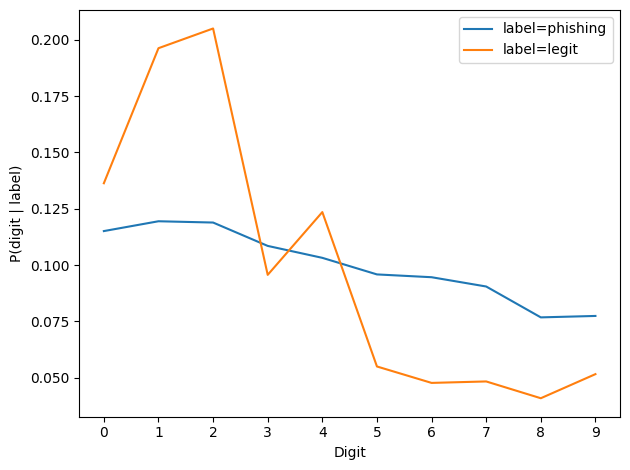

In [126]:
digits = list("0123456789")
digit_counts = (
    data.assign(digit=data["URL"].str.findall(r"\d"))
    .explode("digit")
    .groupby(["label", "digit"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=digits, fill_value=0)
)
digit_probs = digit_counts.div(digit_counts.sum(axis=1), axis=0)

plt.figure()
for label in digit_probs.index:
    tag = "legit" if label == 1 else "phishing"
    plt.plot(digits, digit_probs.loc[label].values, label=f"label={tag}")

plt.xlabel("Digit")
plt.ylabel("P(digit | label)")
plt.legend()
plt.tight_layout()
plt.show()

This plot shows us the probability of the occurrence of each digit given that we know the character is a digit. We see that the digits included in the phishing URLs are distributed more uniformly. This makes sense since most of these domain names are generated randomly. However, the digit distribution of legit URLs are more centered around lower values such as 1 and 2. Next, we look at the probability of seeing a digit in the URL in general.

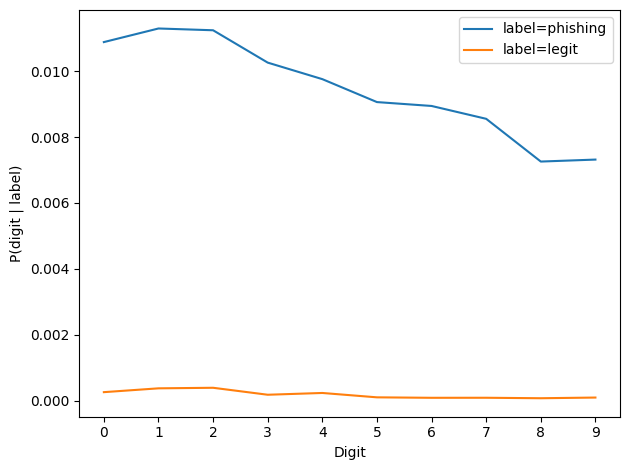

In [127]:
digit_probs_grand = digit_counts.div(data[["label", "URLLength"]].groupby("label").sum()["URLLength"], axis=0)

plt.figure()
for label in digit_probs_grand.index:
    tag = "legit" if label == 1 else "phishing"
    plt.plot(digits, digit_probs_grand.loc[label].values, label=f"label={tag}")

plt.xlabel("Digit")
plt.ylabel("P(digit | label)")
plt.legend()
plt.tight_layout()
plt.show()

We see that the it is not very likely to see a digit in a legit URL. However, phishing URLs include disproportionately high number of digits.